# __Wolf Sheep Predation Model__

_Kelby Mace 03/27/2026_

In [8]:
import random
import math
from dataclasses import dataclass
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

## __Model__

In [7]:
action_to_move = {
    0: (0, 1),     # N
    1: (1, 1),     # NE
    2: (1, 0),     # E
    3: (1, -1),    # SE
    4: (0, -1),    # S
    5: (-1, -1),   # SW
    6: (-1, 0),    # W
    7: (-1, 1),    # NW
    8: (0, 0)      # Stay
}

move_to_action = {v: k for k, v in action_to_move.items()}

@dataclass
class Patch:
    x: int
    y: int
    color: str = "green"
    countdown: int = 0


class Animal:
    def __init__(self, model, x, y, energy):
        self.model = model
        self.x = x
        self.y = y
        self.energy = energy
        self.heading = random.uniform(0, 360)
        self.alive = True
        self.label = ""

    def die(self):
        self.alive = False

    def death(self):
        # energy None is used for RL training - deaths just come from predation
        if self.model.model_version in ["sheep-wolves-grass", "rl-training"] and self.energy < 0:
            self.die()


class Sheep(Animal):

    def move(self):
        strategy = self.model.sheep_strategy

        if strategy == "rl":
            self.move_rl()
        elif strategy == "random":
            self.move_random()
        elif strategy == "avoid_wolves":
            self.move_avoid_wolves()
        elif strategy == "flock":
            self.move_flock()
        else:
            raise ValueError(f"The sheep haven't been taught this strategy: {strategy}")
    
    def get_avoid_wolves_action(self):
        """
        Look in a Moore neighborhood of radius = sheep_sight_radius.
        If wolves are found, move in the opposite direction of the average wolf position.
        If no wolves are found, move randomly.
        """
        radius = self.model.wolf_sight_radius
        nearby_wolves = self.model.get_animals_in_neighborhood(self.x, self.y, radius, animal_type="wolves")

        if not nearby_wolves:
            return random.choice(list(action_to_move.keys()))

        # Compute average relative direction toward wolves
        dx_total = 0
        dy_total = 0

        for wolf in nearby_wolves:
            dx = self.model.wrap_delta(self.x, wolf.x, self.model.width)
            dy = self.model.wrap_delta(self.y, wolf.y, self.model.height)
            dx_total += dx
            dy_total += dy

        # Move opposite the wolves
        move_dx = int(-np.sign(dx_total))
        move_dy = int(-np.sign(dy_total))

        # If exact cancellation happens, fall back to random
        if move_dx == 0 and move_dy == 0:
            return random.choice(list(action_to_move.keys()))

        return move_to_action[(move_dx, move_dy)]
        
    def apply_action(self, action):

        dx, dy = action_to_move[action]
        self.x = (self.x + dx) % self.model.width
        self.y = (self.y + dy) % self.model.height
        self.heading = (math.degrees(math.atan2(dy, dx)) % 360) if not (dx == 0 and dy == 0) else self.heading
    
    def move_rl(self):
        obs = self.model.get_sheep_observation(self)
        action, log_prob = choose_action(self.model.policy_net, obs)
        self.apply_action(action)

        if self.model.collect_log_probs:
            self.model.current_episode_log_probs.append(log_prob)
    
    def move_random(self):

        self.heading += random.randint(0, 49)
        self.heading -= random.randint(0, 49)

        radians = math.radians(self.heading)
        dx = round(math.cos(radians))
        dy = round(math.sin(radians))

        self.x = (self.x + dx) % self.model.width
        self.y = (self.y + dy) % self.model.height

    def move_avoid_wolves(self):

        action = self.get_avoid_wolves_action()
        self.apply_action(action)
    
    def move_flock(self):
        """Flocking strategy"""
        radius = self.model.sheep_sight_radius
        nearby_sheep = self.model.get_animals_in_neighborhood(self.x, self.y, radius, animal_type="sheep", exclude=self)

        if not nearby_sheep:
            self.move_random()
            return

        dx_total = 0
        dy_total = 0

        for sheep in nearby_sheep:
            dx = self.model.wrap_delta(self.x, sheep.x, self.model.width)
            dy = self.model.wrap_delta(self.y, sheep.y, self.model.height)
            dx_total += dx
            dy_total += dy

        move_dx = int(np.sign(dx_total))
        move_dy = int(np.sign(dy_total))

        # If direction cancels out, just stay or move randomly
        if move_dx == 0 and move_dy == 0:
            self.move_random()
            return

        new_x = (self.x + move_dx) % self.model.width
        new_y = (self.y + move_dy) % self.model.height

        # Prefer not to step onto a patch that already has sheep
        if not self.model.sheep_at(new_x, new_y):
            self.x = new_x
            self.y = new_y
            return

        # Fallback: look for an adjacent empty cell that is next to sheep
        candidates = []
        for dx, dy in self.model.moore_directions(include_stay=False):
            cx = (self.x + dx) % self.model.width
            cy = (self.y + dy) % self.model.height

            if self.model.sheep_at(cx, cy):
                continue

            neighbors = self.model.get_animals_in_neighborhood(cx, cy, 1, animal_type="sheep", exclude=self)
            if neighbors:
                candidates.append((cx, cy))

        if candidates:
            self.x, self.y = random.choice(candidates)
        else:
            self.move_random()

    def eat_grass(self):
        patch = self.model.get_patch(self.x, self.y)
        if patch.color == "green":
            patch.color = "brown"
            self.energy += self.model.sheep_gain_from_food

    def reproduce(self):
        if random.random() * 100 < self.model.sheep_reproduce:
            self.energy /= 2
            child = Sheep(self.model, self.x, self.y, self.energy)
            child.heading = self.heading + random.uniform(0, 360)
            child.move()
            self.model.new_sheep.append(child)

    def step(self):
        self.move()

        if self.model.model_version in ["sheep-wolves-grass", "rl-training"]:
            self.energy -= 1
            self.eat_grass()
            self.death()
        if self.model.model_version == "sheep-wolves-grass":
            self.reproduce()
        


class Wolf(Animal):

    def move(self):
        strategy = self.model.wolf_strategy

        if strategy == "random":
            self.move_random()
        elif strategy == "seek_sheep":
            self.move_seek_sheep()
        else:
            raise ValueError(f"Unknown wolf strategy: {strategy}")

    def move_random(self):
        self.heading += random.randint(0, 49)
        self.heading -= random.randint(0, 49)

        radians = math.radians(self.heading)
        dx = round(math.cos(radians))
        dy = round(math.sin(radians))

        self.x = (self.x + dx) % self.model.width
        self.y = (self.y + dy) % self.model.height
    
    def move_seek_sheep(self):
        """
        Look in a Moore neighborhood of radius = sheep_detection_radius.
        If sheep are found, move toward the average sheep position.
        If no sheep are found, move randomly.
        """
        radius = self.model.wolf_sight_radius
        # nearby_sheep = self.model.get_sheep_in_neighborhood(self.x, self.y, radius)
        nearby_sheep = self.model.get_animals_in_neighborhood(self.x, self.y, radius, animal_type="sheep")

        if not nearby_sheep:
            self.move_random()
            return

        dx_total = 0
        dy_total = 0

        for sheep in nearby_sheep:
            dx = self.model.wrap_delta(self.x, sheep.x, self.model.width)
            dy = self.model.wrap_delta(self.y, sheep.y, self.model.height)
            dx_total += dx
            dy_total += dy

        move_dx = int(np.sign(dx_total))
        move_dy = int(np.sign(dy_total))

        if move_dx == 0 and move_dy == 0:
            self.move_random()
            return

        self.x = (self.x + move_dx) % self.model.width
        self.y = (self.y + move_dy) % self.model.height

    def eat_sheep(self):
        sheep_here = [
            s for s in self.model.sheep
            if s.alive and s.x == self.x and s.y == self.y
        ]
        if sheep_here:
            prey = random.choice(sheep_here)
            prey.die()
            if self.model.model_version == "sheep-wolves-grass":
                self.energy += self.model.wolf_gain_from_food

    def reproduce(self):
        if random.random() * 100 < self.model.wolf_reproduce:
            self.energy /= 2
            child = Wolf(self.model, self.x, self.y, self.energy)
            child.heading = self.heading + random.uniform(0, 360)
            child.move()
            self.model.new_wolves.append(child)

    def step(self):
        self.move()
        if self.model.model_version == "sheep-wolves-grass":
            self.energy -= 1
            self.eat_sheep()
            self.death()
            if self.alive:
                self.reproduce()
        else:
            self.eat_sheep()


class WolfSheepModel:
    def __init__(
        self,
        width=50,
        height=50,
        initial_number_sheep=100,
        initial_number_wolves=50,
        sheep_gain_from_food=4,
        wolf_gain_from_food=20,
        sheep_reproduce=4.0,
        wolf_reproduce=5.0,
        grass_regrowth_time=30,
        model_version="sheep-wolves-grass",
        show_energy=False,
        max_sheep=3000,
        sheep_strategy="random",
        wolf_strategy="random",
        wolf_sight_radius=1,
        sheep_sight_radius=1,
        policy_net=None,
        enable_grass=True,
        rl_death_penalty=-100.0,
        rl_alive_reward=1.0,
        rl_grass_bonus=0.05,
        rl_wolf_d1_penalty=0.5,
        rl_wolf_d2_penalty=0.2
    ):
        self.width = width
        self.height = height

        self.initial_number_sheep = initial_number_sheep
        self.initial_number_wolves = initial_number_wolves
        self.sheep_gain_from_food = sheep_gain_from_food
        self.wolf_gain_from_food = wolf_gain_from_food
        self.sheep_reproduce = sheep_reproduce
        self.wolf_reproduce = wolf_reproduce
        self.grass_regrowth_time = grass_regrowth_time
        self.model_version = model_version
        self.show_energy = show_energy
        self.max_sheep = max_sheep

        self.sheep_strategy = sheep_strategy
        self.wolf_strategy = wolf_strategy
        self.sheep_sight_radius = sheep_sight_radius
        self.wolf_sight_radius = wolf_sight_radius

        self.enable_grass = enable_grass
        self.policy_net = policy_net

        # RL Rewards & penalties
        self.rl_death_penalty = rl_death_penalty
        self.rl_alive_reward = rl_alive_reward
        self.rl_grass_bonus = rl_grass_bonus
        self.rl_wolf_d1_penalty = rl_wolf_d1_penalty
        self.rl_wolf_d2_penalty = rl_wolf_d2_penalty

        self.collect_log_probs = False
        self.current_episode_log_probs = []

        self.patches = []
        self.sheep = []
        self.wolves = []
        self.new_sheep = []
        self.new_wolves = []
        self.ticks = 0

        if self.model_version not in ["sheep-wolves-grass", "sheep-wolves", "rl-training"]:
            raise ValueError(f"Unknown model version: {self.model_version}.\nShould be one of: 'sheep-wolves-grass', 'sheep-wolves', 'rl-training'")

    def get_patch(self, x, y):
        return self.patches[y][x]

    def setup(self):
        self.ticks = 0
        self.sheep = []
        self.wolves = []
        self.new_sheep = []
        self.new_wolves = []
        self.patches = []
        self.current_episode_log_probs = [] # record for rl training

        for y in range(self.height):
            row = []
            for x in range(self.width):
                patch = Patch(x, y)

                if self.model_version == "sheep-wolves-grass":
                    patch.color = random.choice(["green", "brown"])
                    if patch.color == "green":
                        patch.countdown = self.grass_regrowth_time
                    else:
                        patch.countdown = random.randrange(self.grass_regrowth_time)
                else:
                    patch.color = "green"

                row.append(patch)
            self.patches.append(row)
        
        if self.model_version == "rl-training" and not self.enable_grass:
            sheep_energy = None
        else:
            sheep_energy = random.randrange(max(1, 2 * self.sheep_gain_from_food))
        wolf_energy = None if self.model_version == "rl-training" else random.randrange(max(1, 2 * self.wolf_gain_from_food))

        for _ in range(self.initial_number_sheep):
            x = random.randrange(self.width)
            y = random.randrange(self.height)
            if self.model_version in ["sheep-wolves-grass", "rl-training"]:
                energy = random.randrange(2 * self.sheep_gain_from_food)
            self.sheep.append(Sheep(self, x, y, energy))

        for _ in range(self.initial_number_wolves):
            x = random.randrange(self.width)
            y = random.randrange(self.height)
            if self.model_version == "sheep-wolves-grass":
                energy = random.randrange(2 * self.wolf_gain_from_food)
            self.wolves.append(Wolf(self, x, y, energy))

        self.display_labels()

    def grow_grass(self):
        for row in self.patches:
            for patch in row:
                if patch.color == "brown":
                    if patch.countdown <= 0:
                        patch.color = "green"
                        patch.countdown = self.grass_regrowth_time
                    else:
                        patch.countdown -= 1

    def grass(self):
        if self.model_version in ["sheep-wolves-grass", "rl-training"]:
            return [
                patch
                for row in self.patches
                for patch in row
                if patch.color == "green"
            ]
        return 0

    def display_labels(self):
        for s in self.sheep:
            s.label = ""
        for w in self.wolves:
            w.label = ""

        if self.show_energy:
            for w in self.wolves:
                w.label = str(round(w.energy))
            if self.model_version == "sheep-wolves-grass":
                for s in self.sheep:
                    s.label = str(round(s.energy))
                    
    def moore_directions(self, include_stay=False):
        directions = [
            (-1, -1), (0, -1), (1, -1),
            (-1,  0),          (1,  0),
            (-1,  1), (0,  1), (1,  1),
        ]
        if include_stay:
            directions.append((0, 0))
        return directions

    def wrap_delta(self, source, target, size):
        """
        Smallest signed wrapped displacement from source to target.
        """
        delta = target - source
        if delta > size / 2:
            delta -= size
        elif delta < -size / 2:
            delta += size
        return delta

    def get_patch(self, x, y):
        return self.patches[y][x]
    
    def sheep_at(self, x, y):
        return [s for s in self.sheep if s.alive and s.x == x and s.y == y]
    
    def get_animals_in_neighborhood(self, x, y, radius, animal_type, exclude=None):
        """
        Return animals of the requested type within a Moore neighborhood
        of the given radius around (x, y).

        animal_type should be either "sheep" or "wolves".
        """
        if animal_type == "sheep":
            animals = self.sheep
        elif animal_type == "wolves":
            animals = self.wolves
        else:
            raise ValueError(f"Unknown animal_type: {animal_type}")

        found = []
        for animal in animals:
            if not animal.alive:
                continue
            if exclude is not None and animal is exclude:
                continue

            dx = self.wrap_delta(x, animal.x, self.width)
            dy = self.wrap_delta(y, animal.y, self.height)

            if max(abs(dx), abs(dy)) <= radius:
                found.append(animal)

        return found
    
    def get_sheep_observation(self, sheep):
        """
        RL observation for a sheep:
        - wolf presence in each cell of local Moore neighborhood
        - grass presence in each cell of local Moore neighborhood
        - sheep's current energy (normalized)
        """
        radius = self.sheep_sight_radius

        wolf_obs = []
        grass_obs = []

        for dy in range(-radius, radius + 1):
            for dx in range(-radius, radius + 1):
                x = (sheep.x + dx) % self.width
                y = (sheep.y + dy) % self.height

                wolf_present = any(
                    w.alive and w.x == x and w.y == y
                    for w in self.wolves
                )
                wolf_obs.append(1.0 if wolf_present else 0.0)

                if self.enable_grass:
                    patch = self.get_patch(x, y)
                    grass_present = 1.0 if patch.color == "green" else 0.0
                else:
                    grass_present = 0.0

                grass_obs.append(grass_present)

        # Normalize energy so it is on a similar scale to the 0/1 inputs
        if sheep.energy is None:
            energy_obs = [0.0]
        else:
            energy_obs = [sheep.energy / max(1, self.sheep_gain_from_food * 2)]

        return wolf_obs + grass_obs + energy_obs
    
    def neighbor_distance(self, x1, y1, x2, y2):
        """
        Moore distance on a toroidal grid.
        """
        dx = self.wrap_delta(x1, x2, self.width)
        dy = self.wrap_delta(y1, y2, self.height)
        return max(abs(dx), abs(dy))
    
    def count_wolves_at_distance(self, sheep, distance):
        """
        Count living wolves at the given distance from the sheep.
        """
        count = 0
        for wolf in self.wolves:
            if not wolf.alive:
                continue
            if self.neighbor_distance(sheep.x, sheep.y, wolf.x, wolf.y) == distance:
                count += 1
        return count
    
    def get_reward(self, sheep, grass_eaten=False):
        """
        RL reward:
        - base reward for surviving the step
        - strong death penalty
        - negative shaping for nearby wolves
        - optional small positive shaping for energy gain
        """

        # If sheep died, return death penalty immediately
        if sheep is None or not sheep.alive:
            return self.rl_death_penalty

        reward = self.rl_alive_reward

        # Penalize nearby wolves by ring
        wolves_d1 = self.count_wolves_at_distance(sheep, 1)
        wolves_d2 = self.count_wolves_at_distance(sheep, 2)

        reward -= self.rl_wolf_d1_penalty * wolves_d1
        reward -= self.rl_wolf_d2_penalty * wolves_d2

        # Optional shaping for positive energy gain
        if grass_eaten:
            reward += self.rl_grass_bonus
        return reward

    def count_sheep(self):
        return len(self.sheep)

    def count_wolves(self):
        return len(self.wolves)

    def patch_array(self):
        """
        Convert patches into a numeric grid for plotting:
        green grass = 1
        brown/no grass = 0
        """
        arr = np.zeros((self.height, self.width))
        for y in range(self.height):
            for x in range(self.width):
                arr[y, x] = 1 if self.patches[y][x].color == "green" else 0
        return arr
    
    def go(self):
        if self.model_version != "rl-training":
            if not self.sheep and not self.wolves:
                return False

            if not self.wolves and self.sheep:
                print("The sheep have inherited the earth")
                return False
        else:
            if len(self.sheep) > 1:
                raise ValueError("Too mnay sheep confuses the shepherd!\n\nrl-training mode expects exactly one sheep or zero after predation.")
        
        if self.model_version == "sheep-wolves-grass":
            self.new_sheep = []
            self.new_wolves = []

        grass_eaten = False
        sheep_before = self.sheep[0] if (self.model_version == "rl-training" and self.sheep) else None
        sheep_energy_before = sheep_before.energy if sheep_before is not None else None

        for sheep in self.sheep[:]:
            if sheep.alive:
                sheep.step()

        self.sheep = [s for s in self.sheep if s.alive]

        for wolf in self.wolves[:]:
            if wolf.alive:
                wolf.step()

        self.wolves = [w for w in self.wolves if w.alive]
        self.sheep = [s for s in self.sheep if s.alive]

        if self.model_version == "sheep-wolves-grass":
            self.sheep.extend(self.new_sheep)
            self.wolves.extend(self.new_wolves)

        if self.model_version in ["sheep-wolves-grass", "rl-training"] and self.enable_grass:
            self.grow_grass()

        self.ticks += 1
        self.display_labels()

        # Return rewards for RL training
        if self.model_version == "rl-training":
            if not self.sheep:
                # print("Our sheep did not survive training.")
                return self.rl_death_penalty, True # reward, done
            sheep_after = self.sheep[0]
            if sheep_energy_before is not None and sheep_after.energy is not None and sheep_after.energy > sheep_energy_before:
                grass_eaten = True
            reward = self.get_reward(sheep_after, grass_eaten=grass_eaten)
            done = False
            return reward, done

        return True

## __Animation__

In [3]:
def animate_model(model, steps=200, interval=150):
    fig, ax = plt.subplots(figsize=(6, 6))

    grass_img = ax.imshow(
        model.patch_array(),
        origin="lower",
        interpolation="nearest",
        cmap="YlGn",
        vmin=0,
        vmax=1
    )

    sheep_scatter = ax.scatter([], [], s=25, marker="o", label="Sheep")
    wolf_scatter = ax.scatter([], [], s=40, marker="s", label="Wolves")

    title = ax.set_title("")
    ax.set_xlim(-0.5, model.width - 0.5)
    ax.set_ylim(-0.5, model.height - 0.5)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.legend(loc="upper right")

    anim = None

    def update(frame):
        running = model.go()

        grass_img.set_data(model.patch_array())

        sheep_xy = np.array([(s.x, s.y) for s in model.sheep]) if model.sheep else np.empty((0, 2))
        wolf_xy = np.array([(w.x, w.y) for w in model.wolves]) if model.wolves else np.empty((0, 2))

        sheep_scatter.set_offsets(sheep_xy)
        wolf_scatter.set_offsets(wolf_xy)

        title.set_text(
            f"Tick {model.ticks} | Sheep: {model.count_sheep()} | Wolves: {model.count_wolves()}"
        )

        if not running and anim is not None:
            anim.event_source.stop()

        return grass_img, sheep_scatter, wolf_scatter, title

    anim = FuncAnimation(
        fig,
        update,
        frames=steps,
        interval=interval,
        blit=False,
        repeat=False
    )

    return anim

## __Reinforcement Learning__

In [14]:
def generate_expert_data(num_samples=5000, model_kwargs=None):
    if model_kwargs is None:
        model_kwargs = {}

    states = []
    actions = []

    expert_kwargs = dict(model_kwargs)
    expert_kwargs["sheep_strategy"] = "avoid_wolves"
    expert_kwargs["wolf_strategy"] = "seek_sheep"

    for _ in range(num_samples):
        model = WolfSheepModel(**expert_kwargs)
        model.setup()

        if len(model.sheep) != 1:
            raise ValueError("Behavior cloning expects exactly one sheep.")

        sheep = model.sheep[0]
        obs = model.get_sheep_observation(sheep)
        action = sheep.get_avoid_wolves_action()

        states.append(obs)
        actions.append(action)

    return (
        torch.tensor(states, dtype=torch.float32),
        torch.tensor(actions, dtype=torch.long)
    )

In [10]:
def pretrain_policy_with_expert(policy_net, num_samples=5000, batch_size=64, num_epochs=10, lr=1e-3, model_kwargs=None):
    states, actions = generate_expert_data(num_samples=num_samples, model_kwargs=model_kwargs)

    dataset = TensorDataset(states, actions)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    optimizer = optim.Adam(policy_net.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()

    losses = []

    policy_net.train()
    for epoch in range(num_epochs):
        epoch_loss = 0.0

        for batch_states, batch_actions in loader:
            logits = policy_net(batch_states)
            loss = loss_fn(logits, batch_actions)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(loader)
        losses.append(avg_loss)
        print(f"Pretrain epoch {epoch + 1}/{num_epochs}, loss = {avg_loss:.4f}")

    return policy_net, losses

In [11]:
class PolicyNetwork(nn.Module):
    def __init__(self, input_dim=51, hidden_dim=32, num_actions=9):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_actions)
        )

    def forward(self, state):
        return self.net(state)   # returns logits for 9 actions
        
def choose_action(policy_net, obs, greedy=False):

    state = torch.as_tensor(obs, dtype=torch.float32)
    logits = policy_net(state)
    dist = torch.distributions.Categorical(logits=logits)

    if greedy:
        action = torch.argmax(logits)
        log_prob = dist.log_prob(action)
    else:
        action = dist.sample()
        log_prob = dist.log_prob(action)

    return int(action.item()), log_prob

def compute_returns(rewards, gamma=0.99):
    returns = []
    G = 0.0
    for r in reversed(rewards):
        G = r + gamma * G
        returns.insert(0, G)

    returns = torch.tensor(returns, dtype=torch.float32)
    if len(returns) > 1:
        returns = (returns - returns.mean()) / (returns.std() + 1e-8)
    return returns


def train_policy_gradient(num_episodes=1000, gamma=0.99, learning_rate=1e-3, max_steps=200, model_kwargs=None, pretrain_with_expert=False, pretrain_samples=5000, pretrain_epochs=10, pretrain_lr=1e-3):

    model_kwargs = dict(model_kwargs or {})
    sight_radius = model_kwargs.get("sheep_sight_radius", 2)
    cells = (2 * sight_radius + 1) ** 2
    input_dim = cells * 2 + 1 # 2x for wolf and grass preesence, +1 for the current energy level

    policy_net = PolicyNetwork(input_dim=input_dim, hidden_dim=32, num_actions=9)

    if pretrain_with_expert:
        policy_net, pretrain_losses = pretrain_policy_with_expert(
            policy_net,
            num_samples=pretrain_samples,
            num_epochs=pretrain_epochs,
            lr=pretrain_lr,
            model_kwargs=model_kwargs,
        )

    optimizer = torch.optim.Adam(policy_net.parameters(), lr=learning_rate)

    default_kwargs = {
        "width": 25,
        "height": 25,
        "initial_number_sheep": 1,
        "initial_number_wolves": 5,
        "model_version": "rl-training",
        "sheep_strategy": "rl",
        "wolf_strategy": "seek_sheep",
        "enable_grass": True,
        "grass_regrowth_time": 30,
        "policy_net": policy_net,
        "sheep_sight_radius": sight_radius,
        "wolf_sight_radius": model_kwargs.get("wolf_sight_radius", 2),
    }
    default_kwargs.update(model_kwargs)

    episode_lengths = []
    best_avg_len = 0 # Keep track of the best policy during training and save that one

    for episode in range(num_episodes):
        model = WolfSheepModel(**default_kwargs)
        model.collect_log_probs = True
        model.setup()

        rewards = []
        done = False
        steps = 0

        while not done and steps < max_steps:
            reward, done = model.go()
            rewards.append(reward)
            steps += 1

        returns = compute_returns(rewards, gamma=gamma)
        loss = 0
        for log_prob, G in zip(model.current_episode_log_probs, returns):
            loss += -log_prob * G

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        episode_lengths.append(steps)

        if (episode + 1) % 50 == 0:
            avg_len = sum(episode_lengths[-50:]) / min(50, len(episode_lengths))
            print(f"Episode {episode + 1}: avg length over last 50 = {avg_len:.2f}")

            if avg_len > best_avg_len:
                best_avg_len = avg_len
                torch.save(policy_net.state_dict(), "best_sheep_policy_1.2.pt")

    return policy_net, episode_lengths


def load_policy(path, input_dim, hidden_dim=32, num_actions=9):
    policy_net = PolicyNetwork(input_dim=input_dim, hidden_dim=hidden_dim, num_actions=num_actions)
    policy_net.load_state_dict(torch.load(path, map_location="cpu"))
    policy_net.eval()
    return policy_net

## __Reinforcement Learning Training__

In [15]:
policy_net, episode_lengths = train_policy_gradient(
    num_episodes=2000,
    gamma=0.99,
    pretrain_with_expert=True,
    pretrain_samples=8000,
    pretrain_epochs=15,
    pretrain_lr=1e-3,
    model_kwargs={
        "width": 10,
        "height": 10,
        "initial_number_sheep": 1,
        "initial_number_wolves": 1,
        "model_version": "rl-training",
        "sheep_strategy": "rl",
        "wolf_strategy": "seek_sheep",
        "enable_grass": True,
        "sheep_sight_radius": 2,
        "wolf_sight_radius": 2,
        "grass_regrowth_time": 20,
    }
)

Pretrain epoch 1/15, loss = 2.1795
Pretrain epoch 2/15, loss = 2.1324
Pretrain epoch 3/15, loss = 2.0501
Pretrain epoch 4/15, loss = 1.9445
Pretrain epoch 5/15, loss = 1.8488
Pretrain epoch 6/15, loss = 1.7801
Pretrain epoch 7/15, loss = 1.7461
Pretrain epoch 8/15, loss = 1.7210
Pretrain epoch 9/15, loss = 1.7116
Pretrain epoch 10/15, loss = 1.7021
Pretrain epoch 11/15, loss = 1.6973
Pretrain epoch 12/15, loss = 1.6940
Pretrain epoch 13/15, loss = 1.6912
Pretrain epoch 14/15, loss = 1.6887
Pretrain epoch 15/15, loss = 1.6881
Episode 50: avg length over last 50 = 43.36
Episode 100: avg length over last 50 = 48.54
Episode 150: avg length over last 50 = 47.52
Episode 200: avg length over last 50 = 79.12
Episode 250: avg length over last 50 = 90.08
Episode 300: avg length over last 50 = 79.58
Episode 350: avg length over last 50 = 86.28
Episode 400: avg length over last 50 = 101.02
Episode 450: avg length over last 50 = 92.20
Episode 500: avg length over last 50 = 64.22
Episode 550: avg le

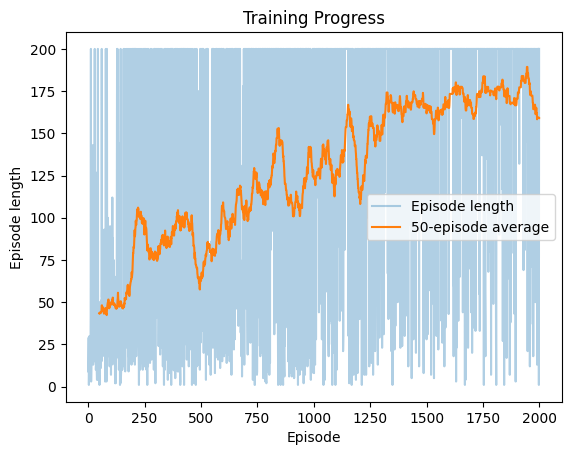

In [16]:
window = 50
moving_avg = np.convolve(
    episode_lengths,
    np.ones(window) / window,
    mode="valid"
)

plt.plot(episode_lengths, alpha=0.35, label="Episode length")
plt.plot(range(window - 1, len(episode_lengths)), moving_avg, label=f"{window}-episode average")
plt.xlabel("Episode")
plt.ylabel("Episode length")
plt.title("Training Progress")
plt.legend()
plt.show()

In [8]:
# torch.save(policy_net.state_dict(), "sheep_policy_1.1.pt")

## __Evaluate Policy__

In [17]:
policy_net = PolicyNetwork(input_dim=51, hidden_dim=32, num_actions=9)
policy_net.load_state_dict(torch.load("best_sheep_policy_1.2.pt"))
policy_net.eval()

PolicyNetwork(
  (net): Sequential(
    (0): Linear(in_features=51, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=9, bias=True)
  )
)

In [21]:
model = WolfSheepModel(
    width=30,
    height=30,
    initial_number_sheep=1,
    initial_number_wolves=5,
    model_version="sheep-wolves-grass",
    sheep_strategy="rl",
    wolf_strategy="seek_sheep",
    enable_grass=True,
    grass_regrowth_time=30,
    sheep_sight_radius=2,
    wolf_sight_radius=3,
    policy_net=policy_net,
)

model.collect_log_probs = False
model.setup()

anim = animate_model(model, steps=50, interval=120)
plt.close(anim._fig)
HTML(anim.to_jshtml())